# Smith Creek Water Level

Use full datalog available at https://docs.google.com/spreadsheets/d/1THImtlWGJqnXo7BfNR9S3TnL1TidwLVEFXZrE_Tv6H0/edit?usp=sharing. Save as .csv then open in text editor (VS code). Remove quotation marks by finding and replacing with nothing.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.dates import DateFormatter

import seaborn as sns

import datetime
import os

from scipy.signal import find_peaks

In [2]:
os.getcwd()

'/Users/bresnahanp/Dropbox/Smart_Coasts_Sensing/Water-Level/Open-Water-Level/Data Analysis'

In [3]:
filepath = os.path.join('Data', 'Water Level 2024 - Sheet1 - 20260518.csv')
df_full = pd.read_csv(filepath, header = None, parse_dates = [1])
df_full.columns = ['Device_ID', 'Datetime Transmission', 'Sensor', 'Event', 'Unix Time', 'Distance (cm)', 'Battery (V)', 'Charge (%)']
df_full.head()

,Device_ID,Datetime Transmission,Sensor,Event,Unix Time,Distance (cm),Battery (V),Charge (%)
0,e00fce680cdac6c15e5dfc75,2024-02-19 22:12:13,waterLevel_0001,waterLevel,1708398731,192.33333,4.13,95.29
1,e00fce686649823d18a012b5,2024-02-19 22:12:13,waterLevel_0000,waterLevel,1708398730,166.67500,4.14,97.66
2,e00fce680cdac6c15e5dfc75,2024-02-19 22:18:12,waterLevel_0001,waterLevel,1708399090,193.43889,4.13,95.29
3,e00fce686649823d18a012b5,2024-02-19 22:18:13,waterLevel_0000,waterLevel,1708399091,206.66945,4.14,97.66
4,e00fce680cdac6c15e5dfc75,2024-02-19 22:24:12,waterLevel_0001,waterLevel,1708399450,194.37361,4.13,95.29


In [4]:
# df_full?

In [5]:
# Size before truncating
len(df_full)

51344

## Interpret Unix time and get rid of junk dates (i.e., before cell connection)

In [6]:
# Filter out bad dates (currently using 1708538411 or 2/21/2024 13:00 ET)
df_full = df_full[df_full['Unix Time']>1708538411]

# to round off to nearest second
time_utc = pd.to_datetime(df_full.loc[:, 'Unix Time']*1000000000)
df_full.loc[:, 'Time (ET)'] = time_utc.dt.tz_localize('utc').dt.tz_convert('US/Eastern')
df_full['Water Level (cm)'] = np.zeros(len(df_full))

df_full.head()

,Device_ID,Datetime Transmission,Sensor,Event,Unix Time,Distance (cm),Battery (V),Charge (%),Time (ET),Water Level (cm)
347,e00fce680cdac6c15e5dfc75,2024-02-21 14:00:11,waterLevel_0001,waterLevel,1708542010,243.78889,4.04,84.34,2024-02-21 14:00:10-05:00,0.0
348,e00fce686649823d18a012b5,2024-02-21 14:00:12,waterLevel_0000,waterLevel,1708542010,406.23056,4.08,86.20,2024-02-21 14:00:10-05:00,0.0
349,e00fce680cdac6c15e5dfc75,2024-02-21 15:00:11,waterLevel_0001,waterLevel,1708545610,246.25139,4.04,84.34,2024-02-21 15:00:10-05:00,0.0
350,e00fce686649823d18a012b5,2024-02-21 15:00:13,waterLevel_0000,waterLevel,1708545611,405.70557,4.08,86.20,2024-02-21 15:00:11-05:00,0.0
351,e00fce680cdac6c15e5dfc75,2024-02-21 16:00:11,waterLevel_0001,waterLevel,1708549210,214.10695,4.03,84.34,2024-02-21 16:00:10-05:00,0.0


In [7]:
# Size after truncating
len(df_full)

50741

## Separate Sensors
Google Sheet contains data from all sensors in the waterLevel product that publish with eventName beginning with waterLevel. Separate data from the two sensors. 

In [8]:
# Filter out values noting that sensor id changed
sensorName = 'waterLevel_0003'
filt_wl = np.where((df_full['Sensor']==sensorName)) # | (df_full['Sensor']=='waterLevel_0002'))
df_selectSensor_withDups = df_full.iloc[filt_wl] # could have duplicate values
df_selectSensor_withDups.head()

,Device_ID,Datetime Transmission,Sensor,Event,Unix Time,Distance (cm),Battery (V),Charge (%),Time (ET),Water Level (cm)
1504,e00fce685b52525503149da9,2024-04-04 16:00:22,waterLevel_0003,waterLevel,1712260819,114.62361,4.08,87.21,2024-04-04 16:00:19-04:00,0.0
1506,e00fce685b52525503149da9,2024-04-04 17:00:26,waterLevel_0003,waterLevel,1712264419,109.60694,4.08,87.21,2024-04-04 17:00:19-04:00,0.0
1507,e00fce685b52525503149da9,2024-04-04 18:00:20,waterLevel_0003,waterLevel,1712268019,117.67083,4.08,87.21,2024-04-04 18:00:19-04:00,0.0
1511,e00fce685b52525503149da9,2024-04-05 12:00:21,waterLevel_0003,waterLevel,1712332819,40.06944,4.07,86.63,2024-04-05 12:00:19-04:00,0.0
1519,e00fce685b52525503149da9,2024-04-05 15:27:55,waterLevel_0003,waterLevel,1712345274,35.22778,4.08,90.86,2024-04-05 15:27:54-04:00,0.0


In [9]:
df_selectSensor = df_selectSensor_withDups.drop_duplicates()
print(f"Length of original DF is {len(df_selectSensor_withDups)}; with duplicates dropped, it's {len(df_selectSensor)}.")

Length of original DF is 21819; with duplicates dropped, it's 21678.


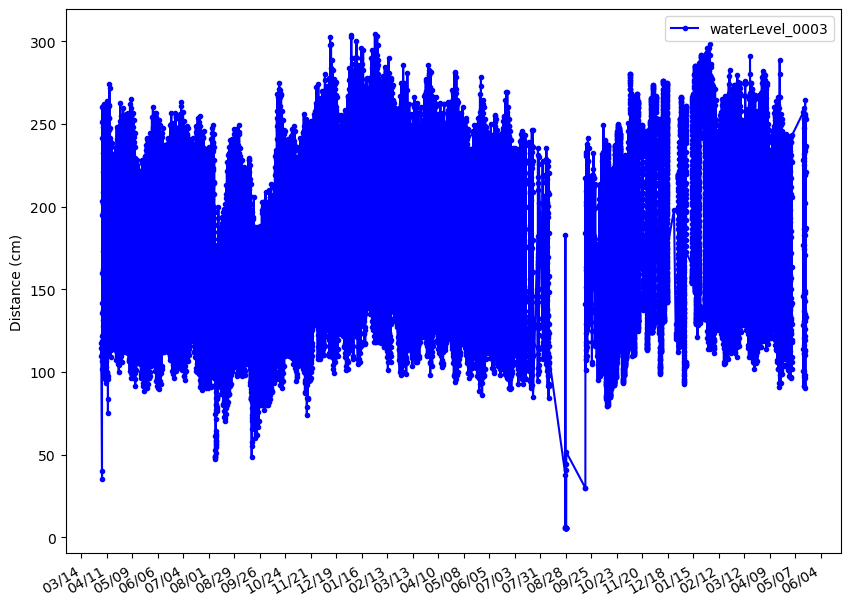

In [10]:
fig, axs = plt.subplots(figsize = (10, 8))
axs.plot(df_selectSensor['Time (ET)'], df_selectSensor['Distance (cm)'], 'b.-', label = sensorName)
axs.set_ylabel('Distance (cm)')
axs.legend()

# xtick dates are poorly spaced
axs.xaxis.set_major_locator(ticker.MultipleLocator(28))

date_form = DateFormatter("%m/%d")
axs.xaxis.set_major_formatter(date_form)

fig.autofmt_xdate()

### Estimate Sensor Uptime
Base estimate on known sampling period

In [11]:
begTime = min(df_selectSensor['Time (ET)'])
endTime = max(df_selectSensor['Time (ET)'])

timeDiff = endTime - begTime
timeDiff_hrs = np.floor(timeDiff.total_seconds()/3600)
print(f"The sensor has been activated for {timeDiff}, which equals {timeDiff_hrs} hours (rounded).\r")
print(f"Array length is {len(df_selectSensor)}.")

The sensor has been activated for 773 days 16:00:14, which equals 18568.0 hours (rounded).
Array length is 21678.


In [12]:
percent_uptime = len(df_selectSensor)/(timeDiff_hrs+1)*100
percent_uptime

np.float64(116.74295869459851)

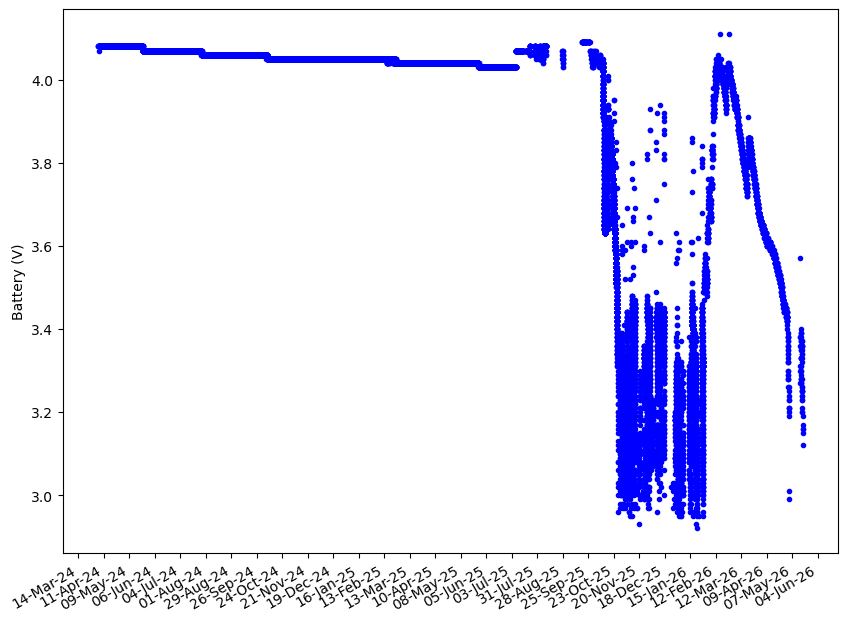

In [13]:
# plt.style.use('dark_background')
fig, axs = plt.subplots(figsize = (10, 8))
axs.plot(df_selectSensor['Time (ET)'], df_selectSensor['Battery (V)'], 'b.')

axs.set_ylabel('Battery (V)')
# axs.legend()

# xtick dates are poorly spaced
axs.xaxis.set_major_locator(ticker.MultipleLocator(28))

# axs.set_xlim([datetime.date(2024, 5, 24), datetime.date(2025, 2, 20)])

date_form = DateFormatter("%d-%b-%y")
axs.xaxis.set_major_formatter(date_form)

fig.autofmt_xdate()

### Replot battery over narrower time window

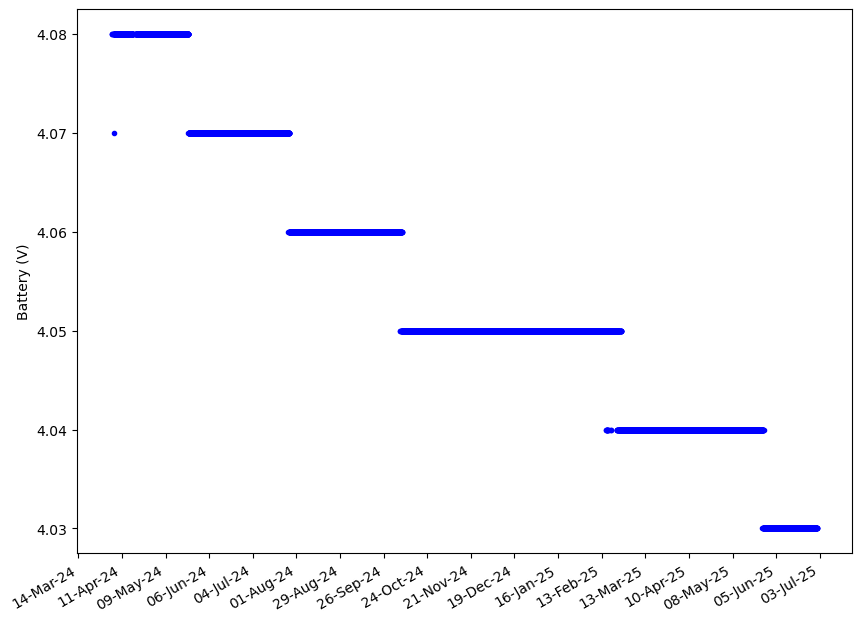

In [14]:
start_date = '2024-04-01'
end_date = '2025-07-01'

df_selectSensor_slice = df_selectSensor[(df_selectSensor['Time (ET)'] >= start_date) & (df_selectSensor['Time (ET)'] <= end_date)]


fig, axs = plt.subplots(figsize = (10, 8))
axs.plot(df_selectSensor_slice['Time (ET)'], df_selectSensor_slice['Battery (V)'], 'b.')

axs.set_ylabel('Battery (V)')
# axs.legend()

# xtick dates are poorly spaced
axs.xaxis.set_major_locator(ticker.MultipleLocator(28))

# axs.set_xlim([datetime.date(2024, 5, 24), datetime.date(2025, 2, 20)])

date_form = DateFormatter("%d-%b-%y")
axs.xaxis.set_major_formatter(date_form)

fig.autofmt_xdate()